In [2]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg

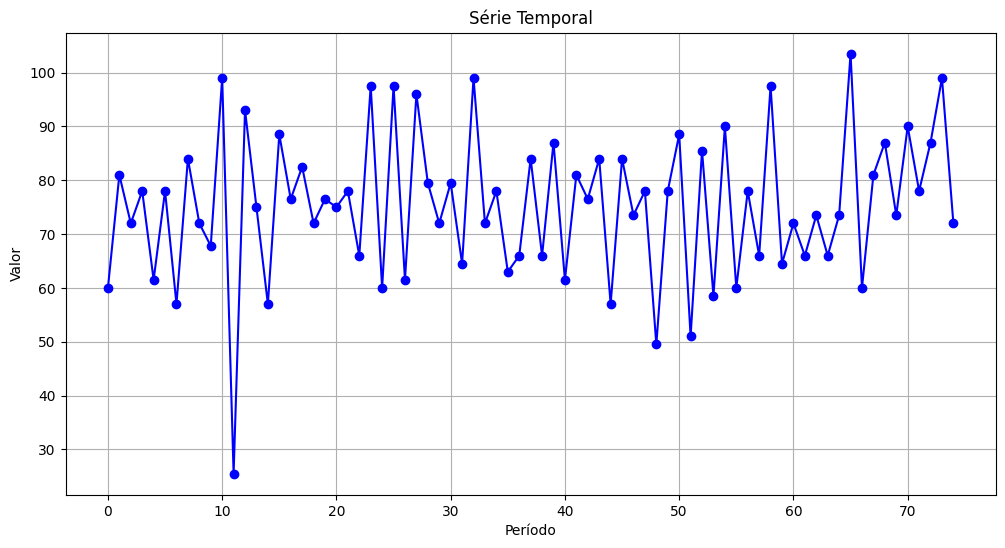

In [ ]:
# Dados da série temporal
series = np.array([
    60.0, 81.0, 72.0, 78.0, 61.5, 78.0, 57.0, 84.0, 72.0, 67.8, 99.0, 25.5,
    93.0, 75.0, 57.0, 88.5, 76.5, 82.5, 72.0, 76.5, 75.0, 78.0, 66.0, 97.5,
    60.0, 97.5, 61.5, 96.0, 79.5, 72.0, 79.5, 64.5, 99.0, 72.0, 78.0, 63.0,
    66.0, 84.0, 66.0, 87.0, 61.5, 81.0, 76.5, 84.0, 57.0, 84.0, 73.5, 78.0,
    49.5, 78.0, 88.5, 51.0, 85.5, 58.5, 90.0, 60.0, 78.0, 66.0, 97.5, 64.5,
    72.0, 66.0, 73.5, 66.0, 73.5, 103.5, 60.0, 81.0, 87.0, 73.5, 90.0, 78.0,
    87.0, 99.0, 72.0
])
# Plot da série temporal
splt.figure(figsize=(12, 6))
plt.plot(series, marker='o', linestyle='-', color='b')
plt.title("Série Temporal")
plt.xlabel("Período")
plt.ylabel("Valor")
plt.grid(True)
plt.show()


In [5]:
# Ajuste dos modelos AR(2) e AR(3)
model_ar2 = AutoReg(series, lags=2).fit()
model_ar3 = AutoReg(series, lags=3).fit()

# Parâmetros dos modelos
params_ar2 = model_ar2.params
params_ar3 = model_ar3.params

# Exibir os parâmetros
print("Parâmetros do modelo AR(2):")
print(params_ar2)

print("\nParâmetros do modelo AR(3):")
print(params_ar3)

Parâmetros do modelo AR(2):
[ 1.14935315e+02 -5.28880827e-01  4.90523095e-03]

Parâmetros do modelo AR(3):
[93.30087168 -0.52552808  0.11005637  0.18026002]


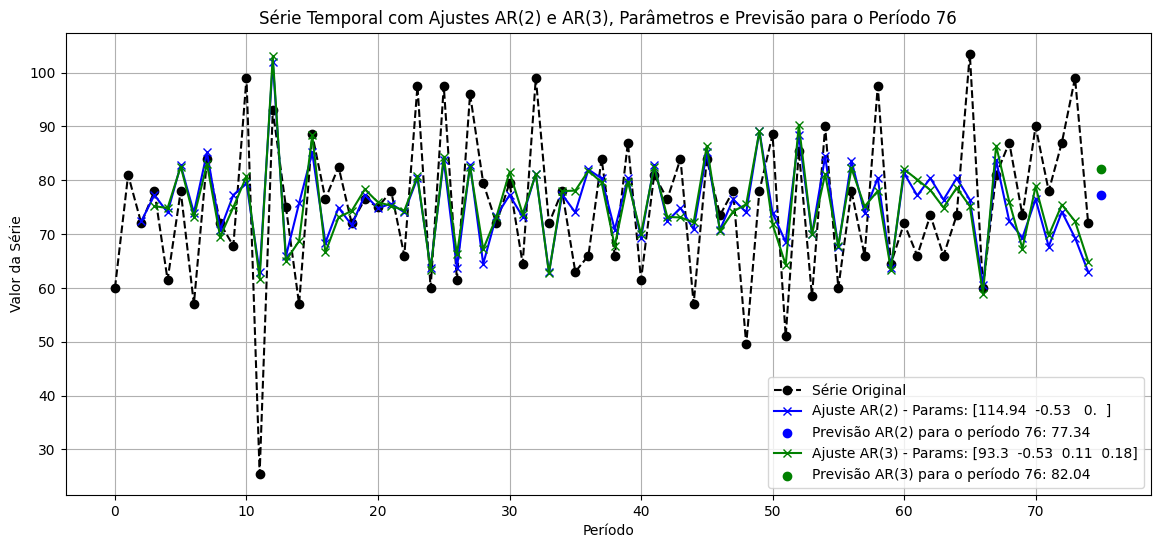

In [6]:
# Previsões dado a dado (valores ajustados) e previsão para o próximo período
fitted_values_ar2 = model_ar2.predict(start=2, end=len(series) - 1)
fitted_values_ar3 = model_ar3.predict(start=3, end=len(series) - 1)
next_prediction_ar2 = model_ar2.predict(start=len(series), end=len(series))
next_prediction_ar3 = model_ar3.predict(start=len(series), end=len(series))

# Visualização
plt.figure(figsize=(14, 6))

# Série temporal original
plt.plot(series, label="Série Original", color="black", marker="o", linestyle="dashed")

# Valores ajustados para AR(2) e previsão para o próximo período
plt.plot(range(2, len(series)), fitted_values_ar2, label=f"Ajuste AR(2) - Params: {np.round(params_ar2, 2)}", color="blue", marker="x")
plt.scatter(len(series), next_prediction_ar2, color="blue", label=f"Previsão AR(2) para o período 76: {next_prediction_ar2[0]:.2f}")

# Valores ajustados para AR(3) e previsão para o próximo período
plt.plot(range(3, len(series)), fitted_values_ar3, label=f"Ajuste AR(3) - Params: {np.round(params_ar3, 2)}", color="green", marker="x")
plt.scatter(len(series), next_prediction_ar3, color="green", label=f"Previsão AR(3) para o período 76: {next_prediction_ar3[0]:.2f}")

# Configurações de layout
plt.xlabel("Período")
plt.ylabel("Valor da Série")
plt.title("Série Temporal com Ajustes AR(2) e AR(3), Parâmetros e Previsão para o Período 76")
plt.legend()
plt.grid()
plt.show()



In [15]:
# Cálculo do Mean Squared Error (MSE) entre os valores ajustados e os valores reais da série
mse_ar2 = mean_squared_error(series[2:], fitted_values_ar2)  # Ignorando os dois primeiros valores devido à defasagem

# Cálculo do Mean Squared Error (MSE) entre os valores ajustados e os valores reais da série
mse_ar3 = mean_squared_error(series[3:], fitted_values_ar3)  # Ignorando os dois primeiros valores devido à defasagem

print(mse_ar2,mse_ar3)


136.14209368558102 133.9772400401187


In [8]:
from statsmodels.tsa.arima.model import ARIMA

# Ajuste do modelo MA(1) - apenas o termo de média móvel
model_ma1 = ARIMA(series, order=(0, 0, 1)).fit()

# Previsão para a série e próximo período
fitted_values_ma1 = model_ma1.fittedvalues
next_prediction_ma1 = model_ma1.forecast(steps=1)

# Exibir os parâmetros do modelo MA(1)
params_ma1 = model_ma1.params
print("Parâmetros do modelo MA(1):")
print(params_ma1)


Parâmetros do modelo MA(1):
[ 75.27105719  -0.398386   148.44658216]


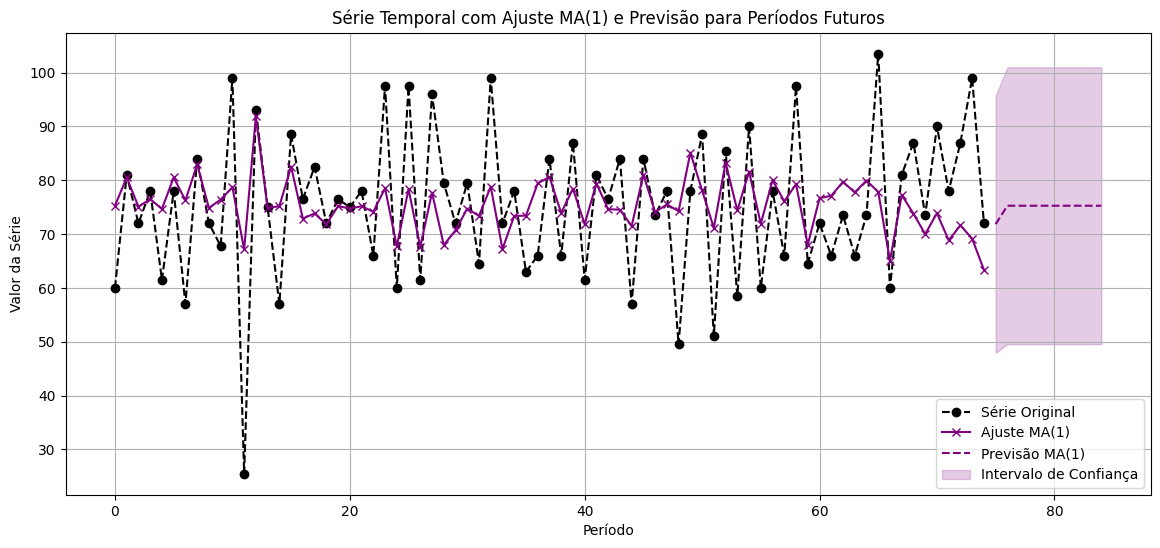

In [11]:
# Previsão para toda a série e próximo período
fitted_values_ma1 = model_ma1.fittedvalues
forecast_values = model_ma1.get_forecast(steps=10)  # Previsão para 10 períodos à frente
forecast_index = np.arange(len(series), len(series) + 10)

# Obter intervalo de confiança
forecast_ci = forecast_values.conf_int()

# Visualização da série temporal e previsão
plt.figure(figsize=(14, 6))

# Série temporal original
plt.plot(series, label="Série Original", color="black", marker="o", linestyle="dashed")

# Valores ajustados para MA(1)
plt.plot(fitted_values_ma1, label="Ajuste MA(1)", color="purple", marker="x")

# Previsão para os próximos períodos
plt.plot(forecast_index, forecast_values.predicted_mean, color="purple", linestyle="--", label="Previsão MA(1)")
plt.fill_between(forecast_index, forecast_ci[:, 0], forecast_ci[:, 1], color="purple", alpha=0.2, label="Intervalo de Confiança")

# Configurações de layout
plt.xlabel("Período")
plt.ylabel("Valor da Série")
plt.title("Série Temporal com Ajuste MA(1) e Previsão para Períodos Futuros")
plt.legend()
plt.grid()
plt.show()

In [12]:
from sklearn.metrics import mean_squared_error

# Cálculo do Mean Squared Error (MSE) entre os valores ajustados e os valores reais da série
mse_ma1 = mean_squared_error(series[1:], fitted_values_ma1[1:])  # Ignorando o primeiro valor por falta de previsão

mse_ma1


np.float64(147.73378670012744)